# Exercise 5.13 — Opinion Diffusion in a Ring of Five People
**Sayama, *Introduction to the Modeling and Analysis of Complex Systems*, Section 5**

---

**Problem:** Five people sit in a ring. Each person is connected to her two nearest neighbors (left and right). Initially they hold random opinions (real numbers). At every time step, each person updates her opinion to the local average — her own opinion plus her two neighbors' opinions, divided by 3. Write these dynamics as a linear difference equation, then study asymptotic behavior via eigenvalues and eigenvectors.

## 1. The Ring Structure and Update Rule

Label the five people 1 through 5 arranged in a ring:

    1 — 2 — 3 — 4 — 5 — (back to 1)

Person 1's neighbors are 2 and 5. Person 2's neighbors are 1 and 3. And so on — the ring wraps around, so person 5's neighbors are 4 and 1.

The update rule for person i at each time step is:

    opinion_i(t) = (1/3) * [opinion_{i-1}(t-1) + opinion_i(t-1) + opinion_{i+1}(t-1)]

where indices wrap around (mod 5).

This is a **local averaging** process — each person nudges their view toward the local consensus in their neighborhood.

## 2. Writing the Dynamics as a Linear Difference Equation

Let the state vector x(t) = [x1, x2, x3, x4, x5] hold all five opinions at time t.

The update rule applied to all five people simultaneously gives the matrix equation:

    x(t) = A * x(t-1)

where A is the **transition matrix** (from Code 5.7 in Sayama):

         [ 1/3  1/3   0    0   1/3 ]
         [ 1/3  1/3  1/3   0    0  ]
    A =  [  0   1/3  1/3  1/3   0  ]
         [  0    0   1/3  1/3  1/3 ]
         [ 1/3   0    0   1/3  1/3 ]

Reading row 1: person 1's new opinion is (1/3) of persons 1, 2, and 5 — her own opinion plus her two neighbors.  
Reading row 5: person 5's new opinion is (1/3) of persons 1, 4, and 5 — confirming the ring wraps.

Each **row sums to 1** (it's a weighted average), so A is a **row-stochastic matrix**. This guarantees that the dominant eigenvalue is 1.

Each **column also sums to 1** (by symmetry of the ring), so A is also **doubly stochastic**. This has an important consequence: the mean of all opinions is conserved at every step.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eig, norm

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

## 3. Build the Transition Matrix and Compute Eigenvalues (Code 5.7)

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# TRANSITION MATRIX  (Code 5.7 from Sayama)
# Each row: person i averages her own opinion with her two ring neighbors.
# Row 1: neighbors are person 2 and person 5 (ring wraps)
# ─────────────────────────────────────────────────────────────────────────────

a = 1.0 / 3.0

A = np.array([
    [a, a, 0, 0, a],   # person 1 averages with persons 2 and 5
    [a, a, a, 0, 0],   # person 2 averages with persons 1 and 3
    [0, a, a, a, 0],   # person 3 averages with persons 2 and 4
    [0, 0, a, a, a],   # person 4 averages with persons 3 and 5
    [a, 0, 0, a, a],   # person 5 averages with persons 4 and 1
])

print("Transition matrix A:")
print(np.array2string(A, formatter={'float_kind': lambda x: f'{x:.4f}'}))

# Verify row sums and column sums
print(f"\nRow sums:    {A.sum(axis=1).tolist()}  (each = 1: weighted average ✓)")
print(f"Column sums: {A.sum(axis=0).tolist()}  (each = 1: doubly stochastic ✓)")

# ─────────────────────────────────────────────────────────────────────────────
# EIGENDECOMPOSITION  (Code 5.7 / 5.8 from Sayama)
# np.linalg.eig returns eigenvalues and eigenvectors.
# Columns of the second array are the eigenvectors.
# ─────────────────────────────────────────────────────────────────────────────

eigenvalues, eigenvectors = eig(A)

# Sort by descending absolute value so the dominant eigenvalue is first
sort_idx    = np.argsort(np.abs(eigenvalues))[::-1]
eigenvalues  = eigenvalues[sort_idx].real
eigenvectors = eigenvectors[:, sort_idx].real

print("\nEigenvalues (sorted by |λ|, descending):")
for i, lam in enumerate(eigenvalues):
    dominant = "  ← DOMINANT" if i == 0 else ""
    print(f"  λ_{i+1} = {lam:+.8f}  |λ| = {abs(lam):.8f}{dominant}")

print("\nEigenvectors (columns, matching eigenvalue order):")
print(np.array2string(eigenvectors, formatter={'float_kind': lambda x: f'{x:+.6f}'}))

Transition matrix A:
[[0.3333 0.3333 0.0000 0.0000 0.3333]
 [0.3333 0.3333 0.3333 0.0000 0.0000]
 [0.0000 0.3333 0.3333 0.3333 0.0000]
 [0.0000 0.0000 0.3333 0.3333 0.3333]
 [0.3333 0.0000 0.0000 0.3333 0.3333]]

Row sums:    [1.0, 1.0, 1.0, 1.0, 1.0]  (each = 1: weighted average ✓)
Column sums: [1.0, 1.0, 1.0, 1.0, 1.0]  (each = 1: doubly stochastic ✓)

Eigenvalues (sorted by |λ|, descending):
  λ_1 = +1.00000000  |λ| = 1.00000000  ← DOMINANT
  λ_2 = +0.53934466  |λ| = 0.53934466
  λ_3 = +0.53934466  |λ| = 0.53934466
  λ_4 = -0.20601133  |λ| = 0.20601133
  λ_5 = -0.20601133  |λ| = 0.20601133

Eigenvectors (columns, matching eigenvalue order):
[[-0.447214 +0.024764 -0.632456 -0.079563 +0.632456]
 [-0.447214 +0.608692 -0.195440 -0.304427 -0.511667]
 [-0.447214 +0.351428 +0.511667 +0.572136 +0.195440]
 [-0.447214 -0.391498 +0.511667 -0.621309 +0.195440]
 [-0.447214 -0.593387 -0.195440 +0.433163 -0.511667]]


## 4. Interpreting the Eigenvalues

Since the dynamics are x(t) = A * x(t-1) = A^t * x(0), the long-run behavior is governed by the eigenvalues of A. If we decompose x(0) into eigenvectors:

    x(0) = c_1*v_1 + c_2*v_2 + c_3*v_3 + c_4*v_4 + c_5*v_5

then at time t:

    x(t) = c_1*λ_1^t*v_1 + c_2*λ_2^t*v_2 + ... + c_5*λ_5^t*v_5

Each mode decays or grows according to its eigenvalue:

| Eigenvalue | |λ| | Behavior | Role |
|---|---|---|---|
| λ = 1 | 1 | Constant — never changes | **Conserved quantity** |
| 0 < |λ| < 1 | < 1 | Decays to 0 as t → ∞ | **Transient mode** |
| |λ| > 1 | > 1 | Grows without bound | (Not present here) |

The results show one eigenvalue equal to 1 and four with |λ| < 1. So:
- The component of x(0) aligned with the λ=1 eigenvector **persists forever**
- All other components **decay to zero**
- Asymptotically, x(t) → c_1 * v_1 — the system collapses onto the dominant eigenvector

The dominant eigenvector (corresponding to λ=1) is the **uniform vector** — all five entries equal. This means all opinions converge to the same value: **consensus**.

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# EIGENVALUE INTERPRETATION
# Confirm which eigenvalue is dominant and what its eigenvector looks like.
# ─────────────────────────────────────────────────────────────────────────────

print("=== Eigenvalue Analysis ===")
print()
for i in range(5):
    lam = eigenvalues[i]
    v   = eigenvectors[:, i]
    v_normalized = v / v[np.argmax(np.abs(v))]   # scale so largest entry = ±1
    tag = ""
    if abs(lam - 1.0) < 1e-10:
        tag = "  ← DOMINANT: conserved component"
    elif abs(lam) < 1e-10:
        tag = "  ← zero: this mode vanishes in one step"
    else:
        pct = (1 - abs(lam)) * 100
        tag = f"  ← decays ~{pct:.1f}% per step"
    print(f"λ_{i+1} = {lam:+.6f}  {tag}")
    print(f"   eigenvector: {np.round(v, 6).tolist()}")
    print()

# The conserved quantity
dom_idx = np.argmin(np.abs(eigenvalues - 1.0))
v_dom   = eigenvectors[:, dom_idx]
print("─" * 55)
print(f"Dominant eigenvector (λ=1): {np.round(v_dom, 6).tolist()}")
print("This is a uniform vector — all entries equal.")
print("Consensus value reached = mean of initial opinions (see §6 for proof).")
print()

# Verify: A * v_dom should equal v_dom
residual = norm(A @ v_dom - v_dom)
print(f"Verification: ||A*v_dom - v_dom|| = {residual:.2e}  (should be ~0 ✓)")

=== Eigenvalue Analysis ===

λ_1 = +1.000000    ← DOMINANT: conserved component
   eigenvector: [-0.447214, -0.447214, -0.447214, -0.447214, -0.447214]

λ_2 = +0.539345    ← decays ~46.1% per step
   eigenvector: [0.024764, 0.608692, 0.351428, -0.391498, -0.593387]

λ_3 = +0.539345    ← decays ~46.1% per step
   eigenvector: [-0.632456, -0.19544, 0.511667, 0.511667, -0.19544]

λ_4 = -0.206011    ← decays ~79.4% per step
   eigenvector: [-0.079563, -0.304427, 0.572136, -0.621309, 0.433163]

λ_5 = -0.206011    ← decays ~79.4% per step
   eigenvector: [0.632456, -0.511667, 0.19544, 0.19544, -0.511667]

───────────────────────────────────────────────────────
Dominant eigenvector (λ=1): [-0.447214, -0.447214, -0.447214, -0.447214, -0.447214]
This is a uniform vector — all entries equal.
Consensus value reached = mean of initial opinions (see §6 for proof).

Verification: ||A*v_dom - v_dom|| = 1.92e-16  (should be ~0 ✓)


## 5. Simulate Opinion Diffusion

We now run the model x(t) = A * x(t-1) from random initial opinions and watch convergence to consensus.

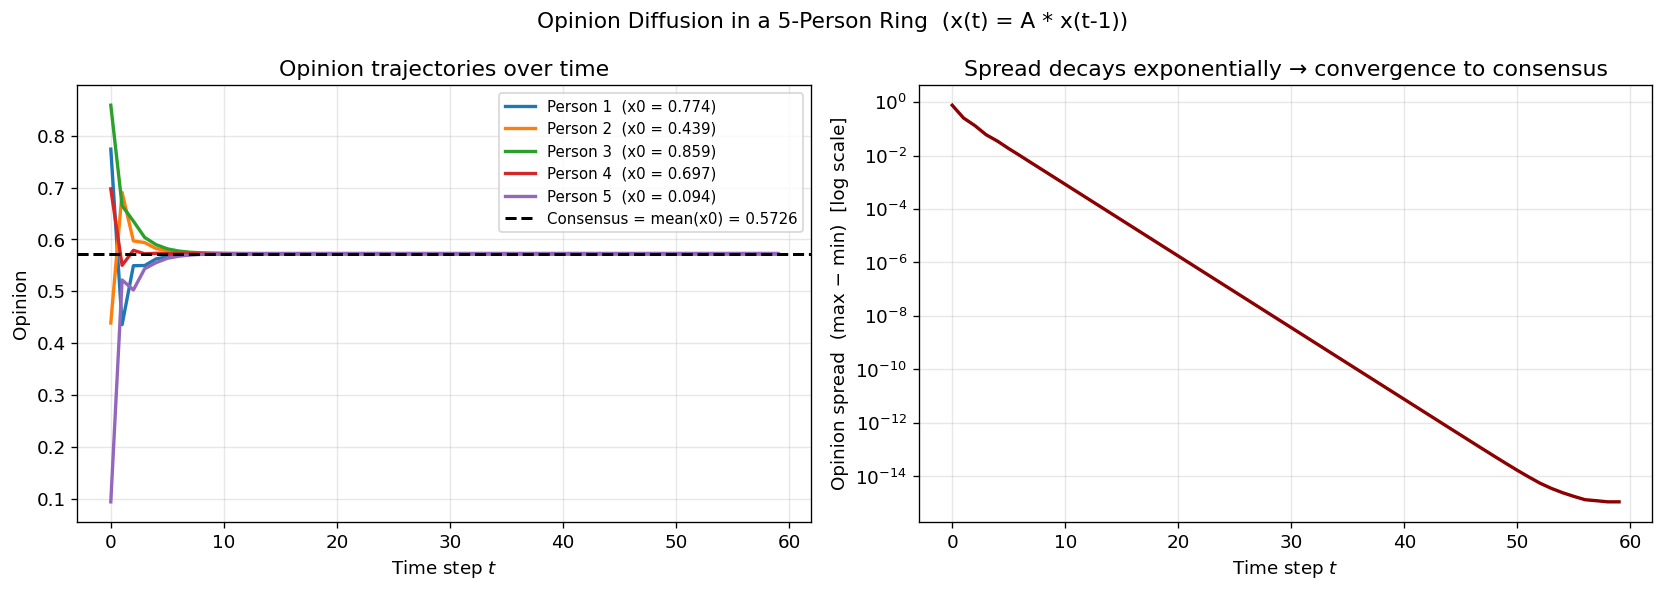

Initial opinions:  [0.774, 0.4389, 0.8586, 0.6974, 0.0942]
Mean (conserved):  0.572596
Final opinions:    [0.572596, 0.572596, 0.572596, 0.572596, 0.572596]
Spread at t=0:     0.764421
Spread at t=59:    1.11e-16  (effectively zero)


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# SIMULATION
# x(t) = A * x(t-1)  iterated from a random initial opinion vector.
# ─────────────────────────────────────────────────────────────────────────────

def simulate_opinions(A, x0, steps=60):
    """Iterate x(t) = A * x(t-1) from initial state x0.
    Returns a (steps x n) array of state vectors.
    """
    n = len(x0)
    history = np.zeros((steps, n))
    history[0] = x0.copy()
    for t in range(1, steps):
        history[t] = A @ history[t-1]
    return history


# ─────────────────────────────────────────────────────────────────────────────
# PLOT 1 — Single run: opinion trajectories and convergence
# ─────────────────────────────────────────────────────────────────────────────

rng  = np.random.default_rng(seed=42)
x0   = rng.uniform(0, 1, size=5)       # random opinions in [0, 1]
consensus_value = np.mean(x0)          # mean is conserved (doubly stochastic)
steps = 60
hist  = simulate_opinions(A, x0, steps)
t_axis = np.arange(steps)

person_colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Opinion Diffusion in a 5-Person Ring  (x(t) = A * x(t-1))', fontsize=13)

# Left: opinion trajectories
ax = axes[0]
for i, col in enumerate(person_colors):
    ax.plot(t_axis, hist[:, i], color=col, lw=2.0,
            label=f'Person {i+1}  (x0 = {x0[i]:.3f})')
ax.axhline(consensus_value, color='black', linestyle='--', lw=1.8,
           label=f'Consensus = mean(x0) = {consensus_value:.4f}')
ax.set_xlabel('Time step $t$')
ax.set_ylabel('Opinion')
ax.set_title('Opinion trajectories over time')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: spread (max - min) decays to 0
ax = axes[1]
spread = hist.max(axis=1) - hist.min(axis=1)   # range of opinions at each step
ax.semilogy(t_axis, spread + 1e-15, color='darkred', lw=2.0)
ax.set_xlabel('Time step $t$')
ax.set_ylabel('Opinion spread  (max − min)  [log scale]')
ax.set_title('Spread decays exponentially → convergence to consensus')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Initial opinions:  {np.round(x0, 4).tolist()}")
print(f"Mean (conserved):  {consensus_value:.6f}")
print(f"Final opinions:    {np.round(hist[-1], 6).tolist()}")
print(f"Spread at t=0:     {spread[0]:.6f}")
print(f"Spread at t={steps-1}:    {spread[-1]:.2e}  (effectively zero)")

## 6. The Conserved Quantity — Why Consensus = Mean of Initial Opinions

Since A is doubly stochastic (row sums = 1 AND column sums = 1), multiplying any vector by A preserves its sum:

    sum of x(t) = sum of A * x(t-1) = [sum of all rows of A] * x(t-1) = 1^T * x(t-1) = sum of x(t-1)

Wait — more carefully: the sum of the output is 1^T * (A * x) = (1^T * A) * x. Since each column of A sums to 1, we have 1^T * A = 1^T, so the sum is 1^T * x — unchanged.

Because the sum is conserved and N=5 is fixed, the **mean is conserved**. Whatever consensus value the five opinions converge to must equal their original mean.

This is directly reflected in the eigenstructure: the λ=1 eigenvector is uniform (all entries equal), so its corresponding coefficient c_1 in the decomposition encodes the mean. That component never changes; all others decay.

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# VERIFY THE CONSERVED MEAN ACROSS MANY RANDOM TRIALS
# ─────────────────────────────────────────────────────────────────────────────

print("=== Conservation of mean — 10 random initial conditions ===")
print(f"{'Trial':>6} | {'Initial mean':>14} | {'Final mean (t=100)':>20} | {'Difference':>12}")
print("-" * 62)

rng2 = np.random.default_rng(seed=7)
for trial in range(10):
    x0_trial = rng2.uniform(-10, 10, size=5)
    hist_trial = simulate_opinions(A, x0_trial, steps=100)
    init_mean  = np.mean(x0_trial)
    final_mean = np.mean(hist_trial[-1])
    diff       = abs(final_mean - init_mean)
    print(f"{trial+1:>6} | {init_mean:>14.6f} | {final_mean:>20.6f} | {diff:>12.2e}")

print("\nMean is conserved to machine precision in every trial ✓")

=== Conservation of mean — 10 random initial conditions ===
 Trial |   Initial mean |   Final mean (t=100) |   Difference
--------------------------------------------------------------
     1 |       1.293474 |             1.293474 |     4.44e-15
     2 |       1.860206 |             1.860206 |     6.88e-15
     3 |      -2.856191 |            -2.856191 |     8.88e-15
     4 |       5.811196 |             5.811196 |     1.42e-14
     5 |      -5.729270 |            -5.729270 |     1.69e-14
     6 |       2.166426 |             2.166426 |     8.88e-15
     7 |      -3.437533 |            -3.437533 |     1.42e-14
     8 |      -3.766456 |            -3.766456 |     1.42e-14
     9 |       2.578359 |             2.578359 |     8.44e-15
    10 |       1.014088 |             1.014088 |     4.00e-15

Mean is conserved to machine precision in every trial ✓


## 7. Eigenvector Decomposition — Watching Each Mode Decay

We can decompose the initial opinion vector x(0) into the eigenvector basis:

    x(0) = c_1*v_1 + c_2*v_2 + c_3*v_3 + c_4*v_4 + c_5*v_5

Then at time t, each mode scales by its eigenvalue raised to the t-th power:

    x(t) = c_1*λ_1^t*v_1 + c_2*λ_2^t*v_2 + ... + c_5*λ_5^t*v_5

The modal coefficients c_k tell us how much of each eigenvector pattern is in the initial condition. The dominant mode (λ=1) stays flat; the others decay geometrically at rates |λ_k|^t.

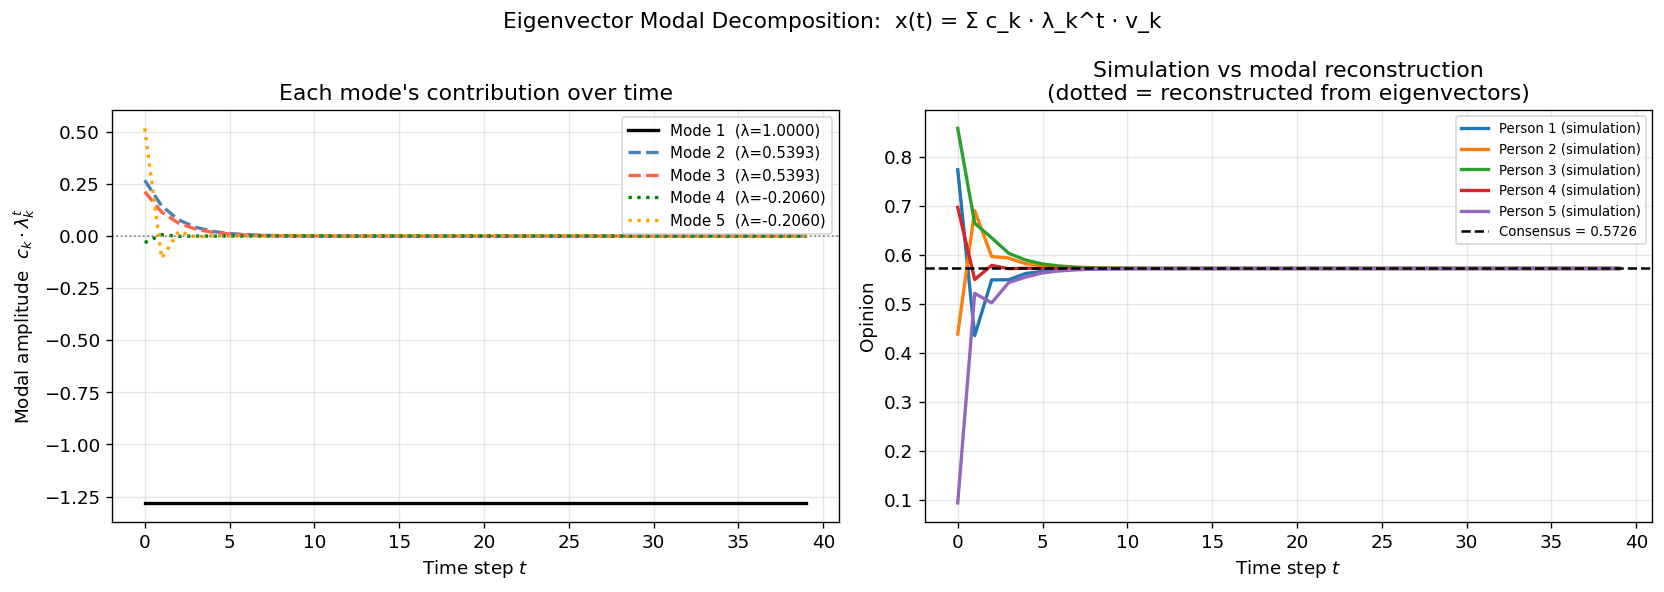

Modal amplitudes at t=0 (c_k):
  Mode 1 (λ=+1.0000):  c_1 = -1.280363
  Mode 2 (λ=+0.5393):  c_2 = +0.267480
  Mode 3 (λ=+0.5393):  c_3 = +0.212937
  Mode 4 (λ=-0.2060):  c_4 = -0.031412
  Mode 5 (λ=-0.2060):  c_5 = +0.516891

Max reconstruction error: 1.44e-15  (simulation = modal sum ✓)

Mode 1 (λ=1) amplitude stays at -1.280363 forever — this IS the conserved component.
Consensus value = c_1 * v_1[0] = -1.280363 * -0.447214 = 0.572596
Actual consensus (mean of x0):   0.572596


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 2 — Modal decomposition: show how each eigenvector component evolves
# c_k(t) = c_k(0) * λ_k^t  (modal amplitude over time)
# ─────────────────────────────────────────────────────────────────────────────

# Use the same x0 as before
# Solve x0 = V * c  →  c = V^{-1} * x0
V    = eigenvectors                     # columns are eigenvectors
c0   = np.linalg.solve(V, x0)          # initial modal amplitudes

steps_modal = 40
t_modal     = np.arange(steps_modal)

# Modal amplitudes over time: c_k(t) = c_k(0) * λ_k^t
modal_amp = np.array([
    [c0[k] * eigenvalues[k]**t for t in t_modal]
    for k in range(5)
])   # shape: (5, steps_modal)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Eigenvector Modal Decomposition:  x(t) = Σ c_k · λ_k^t · v_k', fontsize=13)

mode_colors = ['black', 'steelblue', 'tomato', 'green', 'orange']
mode_styles = ['-', '--', '--', ':', ':']

# Left: modal amplitudes
ax = axes[0]
for k in range(5):
    lam = eigenvalues[k]
    lbl = f'Mode {k+1}  (λ={lam:.4f})'
    ax.plot(t_modal, modal_amp[k], color=mode_colors[k],
            linestyle=mode_styles[k], lw=2.0, label=lbl)
ax.axhline(0, color='gray', linestyle=':', lw=1.0)
ax.set_xlabel('Time step $t$')
ax.set_ylabel('Modal amplitude  $c_k \cdot \lambda_k^t$')
ax.set_title('Each mode\'s contribution over time')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: reconstruction check — sum of modes vs actual simulation
ax = axes[1]
reconstructed = (modal_amp[:, :, np.newaxis] * V.T[:, np.newaxis, :]).sum(axis=0)
# shape: (steps_modal, 5) — opinion of each person reconstructed from modes
# Alternatively, just verify the sum equals the simulation
hist_modal = simulate_opinions(A, x0, steps=steps_modal)
error = np.max(np.abs(reconstructed - hist_modal))

for i, col in enumerate(person_colors):
    ax.plot(t_modal, hist_modal[:, i], color=col, lw=2.0,
            label=f'Person {i+1} (simulation)')
    ax.plot(t_modal, reconstructed[:, i], color=col, lw=1.0,
            linestyle=':', alpha=0.6)
ax.axhline(consensus_value, color='black', linestyle='--', lw=1.5,
           label=f'Consensus = {consensus_value:.4f}')
ax.set_xlabel('Time step $t$')
ax.set_ylabel('Opinion')
ax.set_title('Simulation vs modal reconstruction\n(dotted = reconstructed from eigenvectors)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Modal amplitudes at t=0 (c_k):")
for k in range(5):
    print(f"  Mode {k+1} (λ={eigenvalues[k]:+.4f}):  c_{k+1} = {c0[k]:+.6f}")
print(f"\nMax reconstruction error: {error:.2e}  (simulation = modal sum ✓)")
print(f"\nMode 1 (λ=1) amplitude stays at {c0[0]:.6f} forever — this IS the conserved component.")
print(f"Consensus value = c_1 * v_1[0] = {c0[0]:.6f} * {V[0, 0]:.6f} = {c0[0]*V[0,0]:.6f}")
print(f"Actual consensus (mean of x0):   {consensus_value:.6f}")

## 8. Multiple Random Initial Conditions — Always Reach Consensus

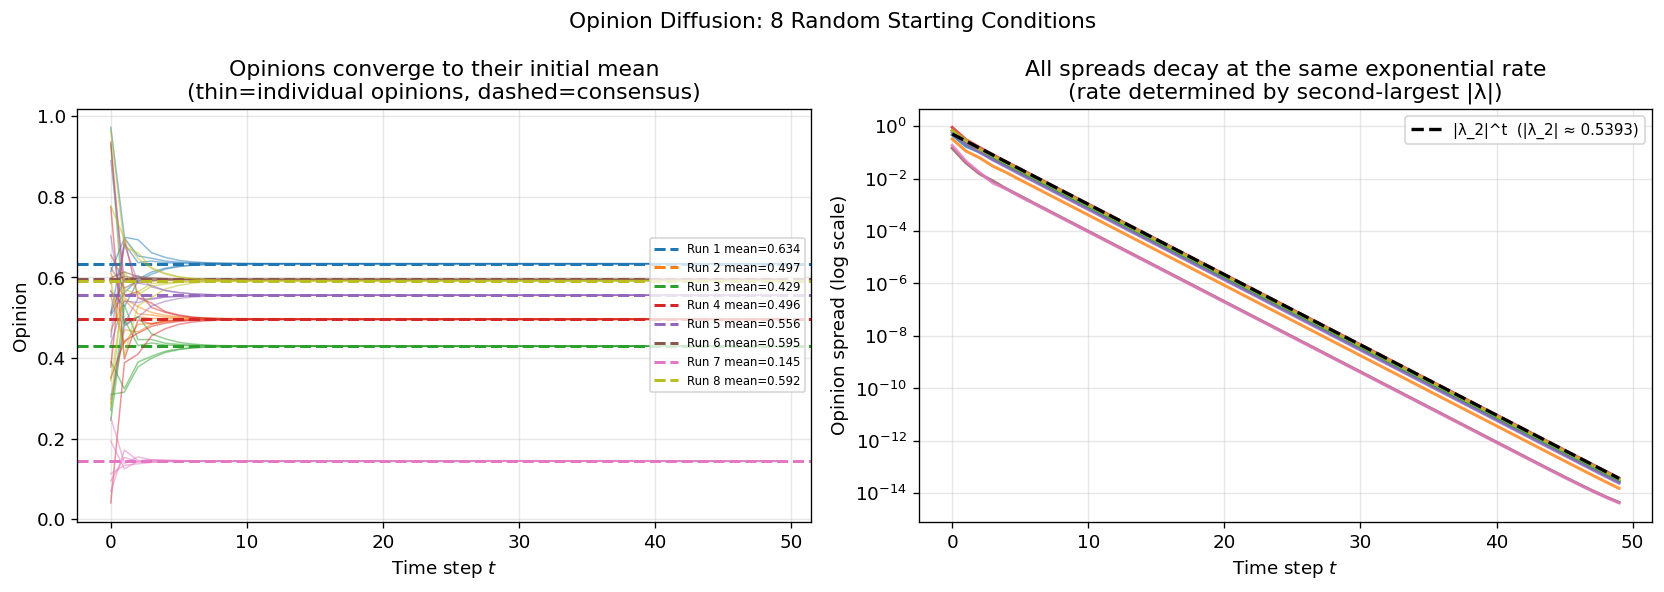

Second-largest |λ| = 0.539345
Spread halving time ≈ log(0.5)/log(0.5393) = 1.1 steps


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 3 — Many random initial conditions: all converge, but to different values
# Each run converges to its own mean — there is no single global attractor,
# just a family of attractors parameterized by the initial mean.
# ─────────────────────────────────────────────────────────────────────────────

n_runs  = 8
steps   = 50
t_axis  = np.arange(steps)
rng3    = np.random.default_rng(seed=99)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Opinion Diffusion: 8 Random Starting Conditions', fontsize=13)

run_colors = plt.cm.tab10(np.linspace(0, 0.8, n_runs))

for run, col in zip(range(n_runs), run_colors):
    x0_r   = rng3.uniform(0, 1, size=5)
    hist_r = simulate_opinions(A, x0_r, steps=steps)
    mean_r = np.mean(x0_r)

    # All 5 opinion lines per run (thin), consensus line (thick)
    for i in range(5):
        axes[0].plot(t_axis, hist_r[:, i], color=col, lw=0.9, alpha=0.5)
    axes[0].axhline(mean_r, color=col, linestyle='--', lw=1.8,
                    label=f'Run {run+1} mean={mean_r:.3f}')

    # Opinion spread per run
    spread_r = hist_r.max(axis=1) - hist_r.min(axis=1)
    axes[1].semilogy(t_axis, spread_r + 1e-15, color=col, lw=1.8, alpha=0.8)

axes[0].set_xlabel('Time step $t$')
axes[0].set_ylabel('Opinion')
axes[0].set_title('Opinions converge to their initial mean\n(thin=individual opinions, dashed=consensus)')
axes[0].legend(fontsize=7, loc='right')
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Time step $t$')
axes[1].set_ylabel('Opinion spread (log scale)')
axes[1].set_title('All spreads decay at the same exponential rate\n(rate determined by second-largest |λ|)')
axes[1].grid(True, alpha=0.3)

# Theoretical decay rate from second-largest eigenvalue
lam_2 = sorted(np.abs(eigenvalues), reverse=True)[1]
t_theory = np.arange(steps)
axes[1].plot(t_theory, 0.5 * lam_2**t_theory, 'k--', lw=2.0,
             label=f'|λ_2|^t  (|λ_2| ≈ {lam_2:.4f})')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"Second-largest |λ| = {lam_2:.6f}")
print(f"Spread halving time ≈ log(0.5)/log({lam_2:.4f}) = "
      f"{np.log(0.5)/np.log(lam_2):.1f} steps")

## 9. Visualizing the Ring Structure

A quick look at how opinions spread geometrically around the ring — the local averaging smooths out differences between neighbors step by step.

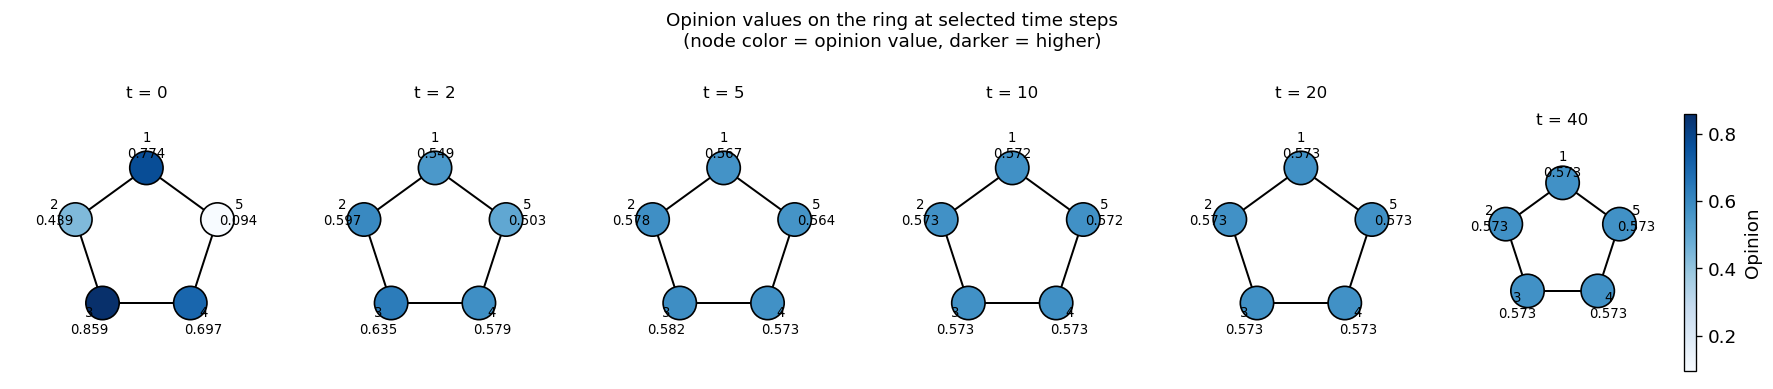

Ring snapshots show local averaging smoothing opinions progressively:
  t=0:  [0.774, 0.439, 0.859, 0.697, 0.094]  (spread = 0.764)
  t=2  : [0.5493, 0.597, 0.6352, 0.5789, 0.5025]  (spread = 1.33e-01)
  t=5  : [0.5666, 0.5782, 0.5818, 0.5727, 0.5636]  (spread = 1.83e-02)
  t=10 : [0.5723, 0.5728, 0.573, 0.5726, 0.5722]  (spread = 8.40e-04)
  t=20 : [0.5726, 0.5726, 0.5726, 0.5726, 0.5726]  (spread = 1.75e-06)
  t=40 : [0.5726, 0.5726, 0.5726, 0.5726, 0.5726]  (spread = 7.59e-12)


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 4 — Ring snapshots: opinions at t=0, 2, 5, 10, 20
# Shows spatial smoothing propagating around the ring.
# ─────────────────────────────────────────────────────────────────────────────

rng4   = np.random.default_rng(seed=42)
x0_ring = rng4.uniform(0, 1, size=5)
hist_ring = simulate_opinions(A, x0_ring, steps=60)

snapshots = [0, 2, 5, 10, 20, 40]
angles    = np.linspace(0, 2 * np.pi, 5, endpoint=False) + np.pi / 2
ring_x    = np.cos(angles)
ring_y    = np.sin(angles)

fig, axes = plt.subplots(1, len(snapshots), figsize=(15, 3.5))
fig.suptitle('Opinion values on the ring at selected time steps\n'
             '(node color = opinion value, darker = higher)', fontsize=11)

vmin = x0_ring.min()
vmax = x0_ring.max()

for ax, t_snap in zip(axes, snapshots):
    opinions = hist_ring[t_snap]
    # Draw ring edges
    for i in range(5):
        j = (i + 1) % 5
        ax.plot([ring_x[i], ring_x[j]], [ring_y[i], ring_y[j]],
                'k-', lw=1.2, zorder=1)
    # Draw nodes colored by opinion
    sc = ax.scatter(ring_x, ring_y, c=opinions, cmap='Blues',
                    vmin=vmin, vmax=vmax, s=400, zorder=3,
                    edgecolors='black', linewidths=1.0)
    # Label each node
    for i in range(5):
        ax.text(ring_x[i] * 1.3, ring_y[i] * 1.3, f'{i+1}\n{opinions[i]:.3f}',
                ha='center', va='center', fontsize=8)
    ax.set_title(f't = {t_snap}', fontsize=10)
    ax.set_xlim(-1.8, 1.8)
    ax.set_ylim(-1.8, 1.8)
    ax.set_aspect('equal')
    ax.axis('off')

plt.colorbar(sc, ax=axes[-1], label='Opinion', shrink=0.8)
plt.tight_layout()
plt.show()

print("Ring snapshots show local averaging smoothing opinions progressively:")
print(f"  t=0:  {np.round(x0_ring, 3).tolist()}  (spread = {x0_ring.max()-x0_ring.min():.3f})")
for t_snap in snapshots[1:]:
    state = hist_ring[t_snap]
    print(f"  t={t_snap:<3}: {np.round(state, 4).tolist()}  (spread = {state.max()-state.min():.2e})")

## 10. Summary

### The Model

    x(t) = A * x(t-1)

where A is the 5x5 circulant matrix with each row containing 1/3 at the diagonal and two neighbor positions, and 0 elsewhere.

### Eigenvalue Results

| Eigenvalue | |λ| | Eigenvector pattern | Consequence |
|---|---|---|---|
| λ = 1 | 1 | Uniform (all equal) | Dominant — conserved; sets the consensus level |
| λ ≈ ±0.539 | < 1 | Oscillatory spatial patterns | Transient — decay to zero |
| λ ≈ ±0.206 | < 1 | Higher-frequency ring patterns | Transient — decay faster |

### Asymptotic Behavior

- **All five opinions converge to the same value** — consensus is guaranteed
- **The consensus value equals the mean of the initial opinions** — because A is doubly stochastic, the mean is an invariant of the dynamics
- **The rate of convergence** is set by the second-largest |λ| ≈ 0.539 — each step the spread shrinks by roughly 46%
- **Initial conditions only determine the consensus level** (via the initial mean), not whether consensus is reached

### Why This Makes Intuitive Sense

Each local averaging step is a contraction: it can only reduce differences between neighbors, never amplify them. The only state it cannot change is one where everyone already agrees — the uniform state. That uniform fixed point has eigenvalue 1; everything else decays.